In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!git clone https://github.com/sakshishah12/llm_from_scratch
%cd llm_from_scratch

Cloning into 'llm_from_scratch'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 47 (delta 22), reused 38 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 131.10 KiB | 8.74 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/llm_from_scratch


In [ ]:
!pip uninstall datasets huggingface_hub -y

!pip install datasets==3.0.1
!pip install huggingface_hub==0.24.7

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: huggingface_hub 1.23.0
Uninstalling huggingface_hub-1.23.0:
  Successfully uninstalled huggingface_hub-1.23.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.6/471.6 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.9/774.9 kB 42.0 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 11.0 MB/s eta 

In [ ]:
!python train.py

2026-07-29 03:00:03.600814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Using device cuda
README.md: 11.4kB [00:00, 6.13MB/s]
train-00000-of-00002.parquet: 100% 185M/185M [00:03<00:00, 61.5MB/s]
train-00001-of-00002.parquet: 100% 185M/185M [00:01<00:00, 103MB/s]
Generating train split: 3067790 examples [00:06, 494247.03 examples/s]
{'idx': 3057078, 'src': 'We have suffered a lot.', 'tgt': 'અમે ખૂબ દર્દ વેઠ્યુ છે.'}
[00:00:09] Pre-processing sequences       ██████████████████ 0        /        0Max length of source sentence: 214
Max length of target sentence: 238
Processign epoch 00: 100% 3750/3750 [16:59<00:00,  3.68it/s, loss=6.082]
--------------------------------------------------------------------------------
SOURCE:Therefore, beg the Mas

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/sakshishah12/llm_from_scratch
%cd llm_from_scratch

Cloning into 'llm_from_scratch'...
remote: Enumerating objects: 47, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 47 (delta 22), reused 38 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (47/47), 131.10 KiB | 994.00 KiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/llm_from_scratch/llm_from_scratch/llm_from_scratch


INFERENCE

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content/llm_from_scratch/llm_from_scratch/llm_from_scratch
['model.py', '.git', 'tokenizer_{0}.json', '__pycache__', 'config.py', 'dataset.py', 'runs', 'train.py']


In [3]:
import torch
import matplotlib.pyplot as plt

from tokenizers import Tokenizer

from config import get_config
from train import get_model, greedy_decode

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

config = get_config()

print(device)
print(config)

cpu
{'batch_size': 24, 'num_epochs': 20, 'lr': 0.0001, 'seq_len': 256, 'd_model': 256, 'lang_src': 'en', 'lang_tgt': 'gu', 'model_folder': '/content/drive/MyDrive/transformer_weights', 'model_basename': 'tmodel_', 'preload': None, 'tokenizer_file': 'tokenizer_{0}.json', 'experiment_name': 'runs/tmodel'}


In [4]:
tokenizer_src = Tokenizer.from_file("tokenizer_en.json")
tokenizer_tgt = Tokenizer.from_file("tokenizer_gu.json")

print(tokenizer_src.get_vocab_size())
print(tokenizer_tgt.get_vocab_size())

26449
30000


In [7]:
model = get_model(
    config,
    tokenizer_src.get_vocab_size(),
    tokenizer_tgt.get_vocab_size()
).to(device)

print(model)

Transformer(
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderBlock(
        (self_attention_block): MultiHeadAttentionBlock(
          (w_q): Linear(in_features=256, out_features=256, bias=True)
          (w_k): Linear(in_features=256, out_features=256, bias=True)
          (w_v): Linear(in_features=256, out_features=256, bias=True)
          (w_o): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward_block): FeedForwardBlock(
          (linear_1): Linear(in_features=256, out_features=2048, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear_2): Linear(in_features=2048, out_features=256, bias=True)
        )
        (residual_connections): ModuleList(
          (0-1): 2 x ResidualConnection(
            (dropout): Dropout(p=0.1, inplace=False)
            (norm): LayerNormalization()
          )
        )
      )
    )
    (norm): LayerNormalization()
 

In [10]:
import os

WEIGHTS_DIR = "/content/drive/MyDrive/transformer_weights"

print(os.listdir(WEIGHTS_DIR))

['tmodel_00.pt', 'tmodel_01.pt', 'tmodel_02.pt', 'tmodel_03.pt', 'tmodel_04.pt', 'tmodel_05.pt', 'tmodel_06.pt', 'tmodel_07.pt', 'tmodel_08.pt', 'tmodel_09.pt', 'tmodel_10.pt', 'tmodel_11.pt', 'tmodel_12.pt', 'tmodel_13.pt', 'tmodel_14.pt', 'tmodel_15.pt', 'tmodel_16.pt', 'tmodel_17.pt', 'tmodel_18.pt', 'tmodel_19.pt']


In [11]:
checkpoint_path = os.path.join(WEIGHTS_DIR, "tmodel_19.pt")

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print(checkpoint.keys())

dict_keys(['epoch', 'model_state_dict', 'optimize_state_dict', 'global_step'])


In [12]:
new_state_dict = {}

for key, value in checkpoint["model_state_dict"].items():
    new_key = key.replace("_orig_mod.", "")
    new_state_dict[new_key] = value

model.load_state_dict(new_state_dict)

model.eval()

print("✅ Weights loaded successfully!")

✅ Weights loaded successfully!


In [13]:
print(os.listdir(WEIGHTS_DIR))

['tmodel_00.pt', 'tmodel_01.pt', 'tmodel_02.pt', 'tmodel_03.pt', 'tmodel_04.pt', 'tmodel_05.pt', 'tmodel_06.pt', 'tmodel_07.pt', 'tmodel_08.pt', 'tmodel_09.pt', 'tmodel_10.pt', 'tmodel_11.pt', 'tmodel_12.pt', 'tmodel_13.pt', 'tmodel_14.pt', 'tmodel_15.pt', 'tmodel_16.pt', 'tmodel_17.pt', 'tmodel_18.pt', 'tmodel_19.pt']


In [ ]:
print("Epoch:", checkpoint["epoch"])
print()

print("Number of parameters:",
      sum(p.numel() for p in model.parameters()))

print()

print(next(iter(model.state_dict())))

Epoch: 19

Number of parameters: 39508592

encoder.layers.0.self_attention_block.w_q.weight


In [32]:
import torch
import torch.nn.functional as F

def beam_search_decode(
    model,
    source,
    source_mask,
    tokenizer_src,
    tokenizer_tgt,
    max_len,
    device,
    beam_size=3,
):
    sos_idx = tokenizer_tgt.token_to_id("[SOS]")
    eos_idx = tokenizer_tgt.token_to_id("[EOS]")

    # Encode source once
    encoder_output = model.encode(source, source_mask)

    # (sequence, score)
    beams = [
        (
            torch.tensor([[sos_idx]], dtype=source.dtype, device=device),
            0.0,
        )
    ]

    completed = []

    while len(beams) > 0:

        candidates = []

        for seq, score in beams:

            # Already finished
            if seq[0, -1].item() == eos_idx:
                completed.append((seq, score))
                continue

            if seq.size(1) >= max_len:
                completed.append((seq, score))
                continue

            decoder_mask = causal_mask(seq.size(1)).type_as(source_mask).to(device)

            decoder_output = model.decode(
                encoder_output,
                source_mask,
                seq,
                decoder_mask,
            )

            logits = model.project(decoder_output[:, -1])

            log_probs = F.log_softmax(logits, dim=-1)

            top_log_probs, top_indices = torch.topk(log_probs, beam_size)

            for k in range(beam_size):

                token = top_indices[0, k].item()
                token_score = top_log_probs[0, k].item()

                new_seq = torch.cat(
                    [
                        seq,
                        torch.tensor(
                            [[token]],
                            dtype=source.dtype,
                            device=device,
                        ),
                    ],
                    dim=1,
                )

                candidates.append(
                    (
                        new_seq,
                        score + token_score,
                    )
                )

        if len(candidates) == 0:
            break

        # Keep best beams
        candidates = sorted(
            candidates,
            key=lambda x: x[1] / (x[0].size(1) ** 0.7),   # length normalization
            reverse=True,
        )

        beams = candidates[:beam_size]

    if len(completed) == 0:
        completed = beams

    completed = sorted(
        completed,
        key=lambda x: x[1] / (x[0].size(1) ** 0.7),
        reverse=True,
    )

    return completed[0][0].squeeze(0)

In [33]:
from dataset import causal_mask

def translate_sentence(sentence):
    """
    Translate one English sentence into Gujarati.
    """

    model.eval()

    # Special tokens
    sos_idx = tokenizer_src.token_to_id("[SOS]")
    eos_idx = tokenizer_src.token_to_id("[EOS]")
    pad_idx = tokenizer_src.token_to_id("[PAD]")

    # Tokenize
    src_tokens = tokenizer_src.encode(sentence).ids

    # Add SOS and EOS
    encoder_input = [sos_idx] + src_tokens + [eos_idx]

    # Check sequence length
    if len(encoder_input) > config["seq_len"]:
        raise ValueError("Sentence is too long!")

    # Pad
    encoder_input += [pad_idx] * (
        config["seq_len"] - len(encoder_input)
    )

    # Tensor
    encoder_input = torch.tensor(
        encoder_input,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    # Encoder mask
    encoder_mask = (
        (encoder_input != pad_idx)
        .unsqueeze(1)
        .unsqueeze(2)
        .int()
        .to(device)
    )

    # Decode
    output = beam_search_decode(
    model,
    encoder_input,
    encoder_mask,
    tokenizer_src,
    tokenizer_tgt,
    config["seq_len"],
    device,
    beam_size=3,   # Try 3 first
)

    # Convert ids → Gujarati text
    prediction = tokenizer_tgt.decode(
        output.detach().cpu().numpy()
    )

    return prediction

In [39]:
examples = [
    "you are intelligent"]

for sentence in examples:
    print("=" * 60)
    print("English :", sentence)
    print("Gujarati:", translate_sentence(sentence))

English : you are intelligent
Gujarati: તમે હોંશિયાર છો .


In [ ]:
encoder_attn = model.encoder.layers[0].self_attention_block.attention_scores

print(type(encoder_attn))

if encoder_attn is not None:
    print("Shape:", encoder_attn.shape)
else:
    print("Attention not found!")

<class 'torch.Tensor'>
Shape: torch.Size([1, 8, 256, 256])


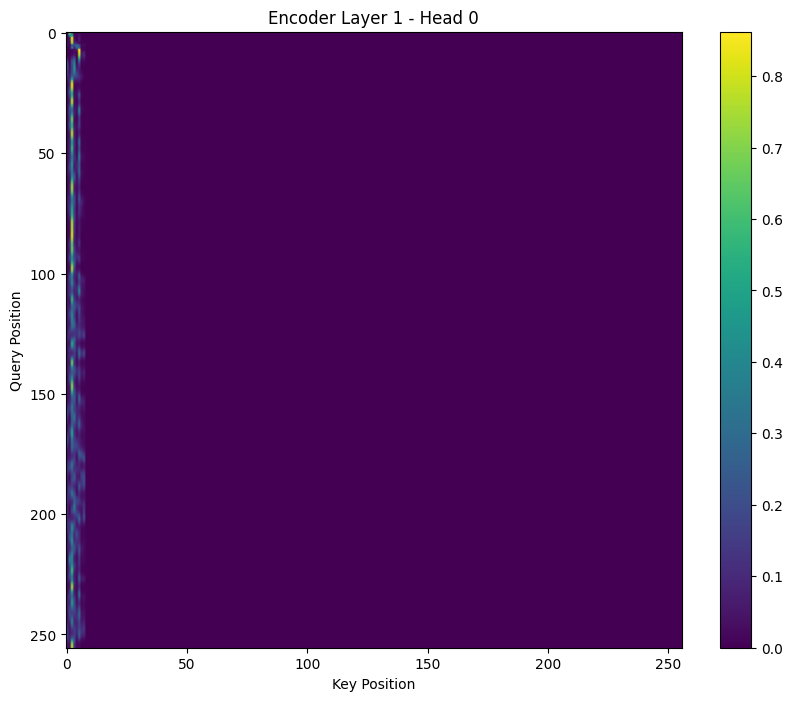

In [ ]:
head = 0

plt.figure(figsize=(10, 8))

plt.imshow(
    encoder_attn[0, head].detach().cpu(),
    cmap="viridis"
)

plt.colorbar()

plt.title(f"Encoder Layer 1 - Head {head}")

plt.xlabel("Key Position")
plt.ylabel("Query Position")

plt.show()

In [ ]:
sentence = "what is your name?"

# Encode the sentence
encoded = tokenizer_src.encode(sentence)

# Actual tokens
tokens = ["[SOS]"] + encoded.tokens + ["[EOS]"]

print(tokens)
print("Number of tokens:", len(tokens))

['[SOS]', 'what', 'is', 'your', 'name', '?', '[EOS]']
Number of tokens: 7


In [ ]:
encoder_attn = model.encoder.layers[0].self_attention_block.attention_scores

num_tokens = len(tokens)

attention = encoder_attn[
    0,          # batch
    0,          # head
    :num_tokens,
    :num_tokens
].detach().cpu()

print(attention.shape)

torch.Size([7, 7])


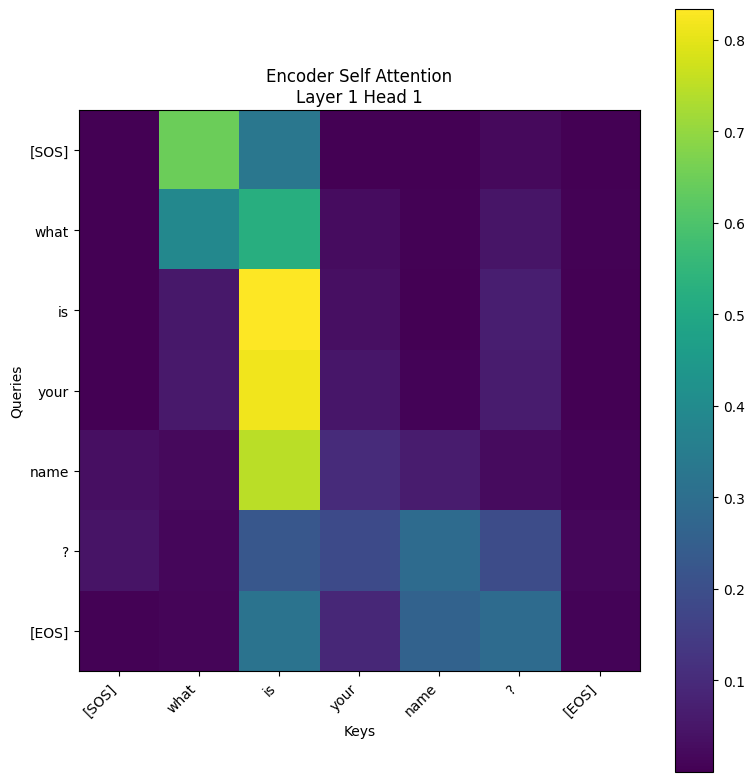

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(attention, cmap="viridis")

plt.xticks(
    range(num_tokens),
    tokens,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(num_tokens),
    tokens
)

plt.xlabel("Keys")
plt.ylabel("Queries")

plt.title("Encoder Self Attention\nLayer 1 Head 1")

plt.colorbar()

plt.tight_layout()

plt.show()

In [ ]:
print(model.src_embed.embedding.weight.shape)
print(tokenizer_src.get_vocab_size())

print(model.tgt_embed.embedding.weight.shape)
print(tokenizer_tgt.get_vocab_size())

torch.Size([26449, 256])
26449
torch.Size([30000, 256])
30000
